In [1]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm as notebook_tqdm
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import numpy as np

In [2]:
oe=OrdinalEncoder()

data=pd.read_csv('/kaggle/input/datasets/ayush500/tweets/Tweets (1).csv')
texts = data['text'].astype(str).tolist()
val=oe.fit_transform(data['sentiment'].values.reshape(1,-1))[0]

In [3]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
encodings = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [5]:
class SimpleDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

dataset = SimpleDataset(encodings, val)
loader = DataLoader(dataset, batch_size=128)

In [6]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=1,
    output_attentions=True  # important
)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
model.train()

for batch in loader:
    optimizer.zero_grad()
    
    batch["labels"] = batch["labels"].float()
    
    outputs = model(**batch)
    loss = outputs.loss
    
    loss.backward()
    optimizer.step()

    print("Loss:", loss.item())

Loss: 0.020744364708662033
Loss: 0.026913361623883247
Loss: 0.019078802317380905
Loss: 0.018344774842262268
Loss: 0.017862722277641296
Loss: 0.01123762782663107
Loss: 0.01359657570719719
Loss: 0.01193112600594759
Loss: 0.01157337799668312
Loss: 0.014268845319747925
Loss: 0.0112904142588377
Loss: 0.009268124587833881
Loss: 0.010200725868344307
Loss: 0.009702641516923904
Loss: 0.009551271796226501
Loss: 0.009558521211147308
Loss: 0.011670350097119808
Loss: 0.008566033095121384
Loss: 0.008411266840994358
Loss: 0.00929007213562727
Loss: 0.009844444692134857
Loss: 0.007843696512281895
Loss: 0.008427327498793602
Loss: 0.006713584531098604
Loss: 0.006257678382098675
Loss: 0.008269441314041615
Loss: 0.0070573934353888035
Loss: 0.005714451428502798
Loss: 0.008424535393714905
Loss: 0.00492154760286212
Loss: 0.004768878687173128
Loss: 0.009267096407711506
Loss: 0.006303697824478149
Loss: 0.005118560045957565
Loss: 0.005050370004028082
Loss: 0.004709694068878889
Loss: 0.004514134488999844
Loss: 0.

In [66]:
model.eval()

inputs = tokenizer("I love this product", return_tensors="pt")
outputs = model(**inputs)

attentions = outputs.attentions  

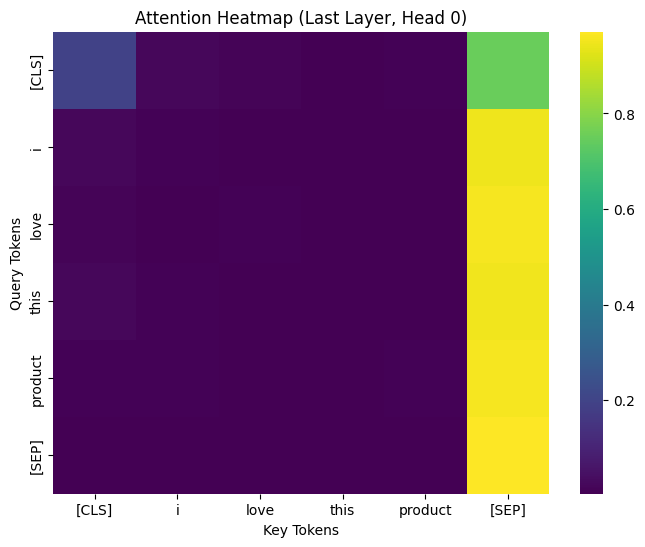

In [67]:
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

attention = attentions[-1][0][0].detach().numpy()  # last layer, head 0

plt.figure(figsize=(8,6))
sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
plt.title("Attention Heatmap (Last Layer, Head 0)")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.show()